# Chess Study — Parameter Impact on Tokens & Success vs. Number of Plies

This notebook analyzes two Concord chess-solver studies and visualizes how solver
parameters affect **token consumption** and **success rate**, segmented by the
**number of plies** (half-moves) in the chess problem.

**The task.** Each run is given a sequence of chess moves in UCI notation and must
produce the final board state in FEN. Longer move sequences (**more plies**) make
the problem harder — there are more transformations to track without error.

**The two studies analyzed**

| Study dir | Design | Plies | What it varies |
|---|---|---|---|
| `20260622-164441` | **Collective** | **5** (easy) | Named presets, each flips *several* parameters at once (`shallow_split`, `deep_split`, `wide_split`, `K1_cheapest`, `K5_diverse`, `big_budget`, `strict_verify`, `lenient_verify`) vs. a `baseline`. |
| `20260622-165017` | **Individual** | **20** (hard) | One-parameter sweeps: `mcts.N ∈ {16,32,64,128,256}` and `pipeline.K_executor ∈ {1,2,3,5}`. |

> ⚠️ **Read the plots with this caveat in mind.** Plies is *confounded* with study
> design: the collective-preset runs were all executed at **5 plies** (and all
> succeeded), while the individual sweeps were executed at **20 plies** (mixed
> success). So "plies vs success rate" here really contrasts two difficulty
> regimes rather than a controlled per-config ply sweep. The notebook is explicit
> about which comparison each figure supports.


In [1]:
# --- Setup -------------------------------------------------------------------
import json, os, re, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

OK   = "#2a9d8f"   # success
FAIL = "#e76f51"   # failure
BASE = "#264653"   # baseline / neutral

In [2]:
# --- Locate the project root & the two study directories ---------------------
def find_project_root(start=None):
    # Walk upward until we find results/chess_study (works from any cwd).
    p = os.path.abspath(start or os.getcwd())
    while True:
        if os.path.isdir(os.path.join(p, "results", "chess_study")):
            return p
        parent = os.path.dirname(p)
        if parent == p:
            break
        p = parent
    # fallback: notebook lives in <repo>/notebooks, so parent of cwd is the repo root
    return os.path.abspath(os.path.join(os.getcwd(), os.pardir))

PROJECT_ROOT = find_project_root()

STUDIES = {
    "20260622-164441": "collective (named presets)",
    "20260622-165017": "individual (param sweeps)",
}

print("PROJECT_ROOT:", PROJECT_ROOT)
for d in STUDIES:
    jl = os.path.join(PROJECT_ROOT, "results", "chess_study", d, "runs.jsonl")
    print(f"  {d}: runs.jsonl exists = {os.path.exists(jl)}")

PROJECT_ROOT: <repo-root>
  20260622-164441: runs.jsonl exists = True
  20260622-165017: runs.jsonl exists = True


In [3]:
# --- Loader: read runs.jsonl + recover the ply count from each trace ---------
def _resolve_trace(trace_path, run_dir):
    # Return an existing absolute path to a run's main trace .jsonl.
    for cand in (trace_path,
                 os.path.join(PROJECT_ROOT, trace_path) if trace_path else None):
        if cand and os.path.exists(cand):
            return cand
    rd = run_dir if os.path.isabs(run_dir or "") else os.path.join(PROJECT_ROOT, run_dir or "")
    for c in glob.glob(os.path.join(rd, "*", "*.jsonl")):
        if "rollouts" not in c and "agent_calls" not in c:
            return c
    return None

def plies_from_trace(trace_file):
    # The number of plies == length of the UCI move sequence in the prompt.
    if not trace_file or not os.path.exists(trace_file):
        return None, None
    for line in open(trace_file):
        o = json.loads(line)
        if o.get("kind") == "problem":
            txt = o["data"].get("text_head", "")
            m = re.search(r"UCI format\):\s*([a-h1-8 ]+)", txt)
            if m:
                moves = m.group(1).split()
                return len(moves), " ".join(moves)
    return None, None

# Roles that may appear in per_role_cost
ROLES = ["execution", "verification", "combiner", "splitter", "decomposition",
         "classification", "synthesizer", "synth_verifier"]

def load_runs():
    recs = []
    for study_dir, study_name in STUDIES.items():
        jl = os.path.join(PROJECT_ROOT, "results", "chess_study", study_dir, "runs.jsonl")
        for line in open(jl):
            o = json.loads(line)
            trace = _resolve_trace(o.get("trace_path"), o.get("run_dir", ""))
            plies, moves = plies_from_trace(trace)
            cost = o.get("cost", {})
            rec = {
                "study": study_dir,
                "study_name": study_name,
                "label": o["label"],
                "vary": o.get("vary"),
                "value": o.get("value"),
                "plies": plies,
                "moves": moves,
                "correct": bool(o.get("overall_correct")),
                "board_match": bool(o.get("overall_board_match")),
                "total_tokens": cost.get("total_tokens"),
                "input_tokens": cost.get("input_tokens"),
                "output_tokens": cost.get("output_tokens"),
                "usd": cost.get("usd"),
                "calls": cost.get("calls"),
                "elapsed_s": o.get("elapsed_s"),
                "rollouts": o.get("rollouts"),
                "atom_pass_rate": o.get("atom_pass_rate"),
                "n_atoms": o.get("n_atoms"),
                "decomp_fidelity": o.get("decomposition_fidelity"),
            }
            for k, v in (o.get("key_params") or {}).items():
                rec[f"kp::{k}"] = v
            prc = o.get("per_role_cost") or {}
            for role in ROLES:
                c = prc.get(role, {})
                rec[f"role_tot::{role}"] = (c.get("input_tokens", 0) or 0) + (c.get("output_tokens", 0) or 0)
            recs.append(rec)
    return pd.DataFrame(recs)

df = load_runs()
print(f"Loaded {len(df)} runs.  Missing ply counts: {df['plies'].isna().sum()}")
print("Distinct ply counts:", sorted(df['plies'].dropna().unique().tolist()))
df[["study_name", "label", "vary", "value", "plies", "correct",
    "total_tokens", "usd", "elapsed_s", "rollouts"]]

Loaded 18 runs.  Missing ply counts: 0
Distinct ply counts: [5, 20]


,study_name,label,vary,value,plies,correct,total_tokens,usd,elapsed_s,rollouts
0,collective (named presets),baseline,NaN,NaN,5,True,58267,0.450573,392.44,64
1,collective (named presets),shallow_split,NaN,NaN,5,True,42681,0.304107,238.12,64
2,collective (named presets),deep_split,NaN,NaN,5,True,61899,0.403437,322.29,1
3,collective (named presets),wide_split,NaN,NaN,5,True,80962,0.618642,542.13,1
4,collective (named presets),K1_cheapest,NaN,NaN,5,True,23649,0.151095,117.29,64
5,collective (named presets),K5_diverse,NaN,NaN,5,True,71265,0.493107,430.39,1
6,collective (named presets),big_budget,NaN,NaN,5,True,54033,0.390123,332.16,128
7,collective (named presets),strict_verify,NaN,NaN,5,True,53720,0.395172,330.76,64
8,collective (named presets),lenient_verify,NaN,NaN,5,True,57921,0.423279,355.18,64
9,individual (param sweeps),mcts.N=16,mcts.N,16.0,20,False,279725,1.866399,1489.56,1


## 1. Headline — difficulty (number of plies) vs. cost & success

The clearest signal in the data: going from a **5-ply** problem to a **20-ply**
problem makes the task dramatically more expensive *and* far less reliable.

In [4]:
plies_summary = (df.groupby("plies")
                   .agg(n_runs=("label", "size"),
                        success_rate=("correct", "mean"),
                        median_tokens=("total_tokens", "median"),
                        median_usd=("usd", "median"),
                        median_elapsed_s=("elapsed_s", "median"))
                   .reset_index())
plies_summary["success_rate"] = (plies_summary["success_rate"] * 100).round(1)
plies_summary

,plies,n_runs,success_rate,median_tokens,median_usd,median_elapsed_s
0,5,9,100.0,57921.0,0.403437,332.16
1,20,9,22.2,189477.0,1.370286,1184.52


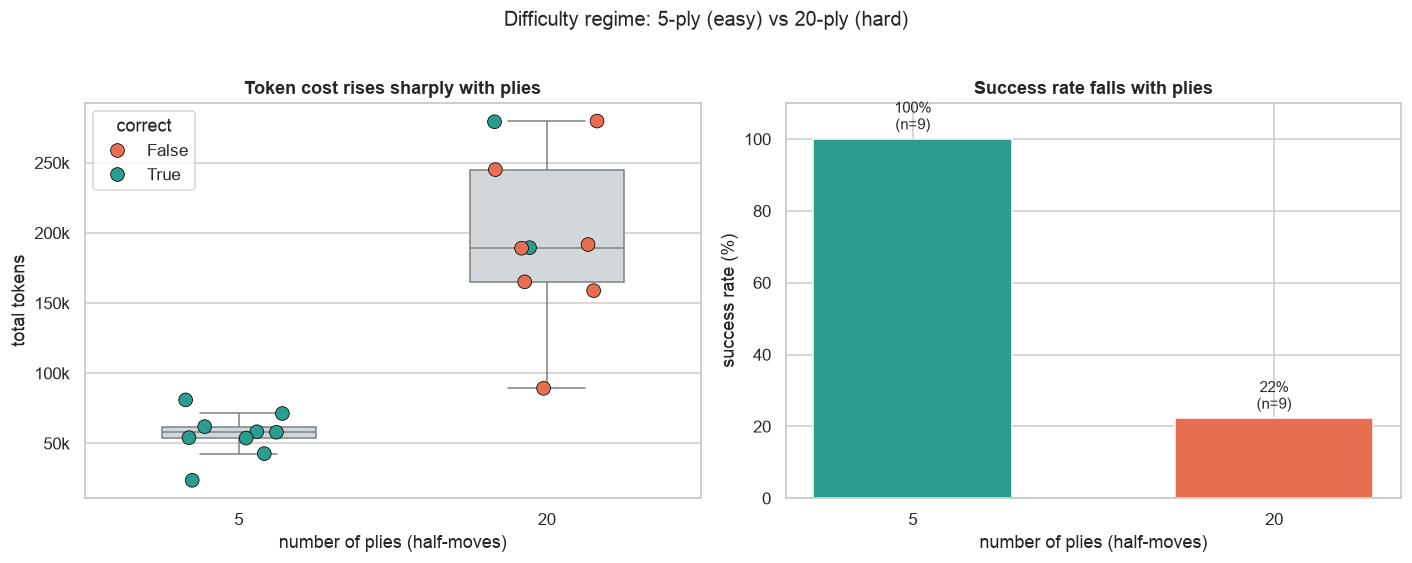

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Left: token distribution by ply count, points colored by correctness
order = sorted(df["plies"].dropna().unique())
sns.boxplot(data=df, x="plies", y="total_tokens", order=order, ax=ax1,
            color="#cfd8dc", width=0.5, showfliers=False)
sns.stripplot(data=df, x="plies", y="total_tokens", order=order, ax=ax1,
              hue="correct", palette={True: OK, False: FAIL},
              size=9, jitter=0.18, edgecolor="black", linewidth=0.5)
ax1.set_title("Token cost rises sharply with plies")
ax1.set_xlabel("number of plies (half-moves)")
ax1.set_ylabel("total tokens")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
ax1.legend(title="correct", loc="upper left")

# Right: success rate by ply count
sr = df.groupby("plies")["correct"].mean().reindex(order) * 100
bars = ax2.bar([str(p) for p in order], sr.values,
               color=[OK if v >= 50 else FAIL for v in sr.values], width=0.55)
for b, v, n in zip(bars, sr.values, df.groupby("plies").size().reindex(order)):
    ax2.text(b.get_x() + b.get_width()/2, v + 1.5, f"{v:.0f}%\n(n={n})",
             ha="center", va="bottom", fontsize=10)
ax2.set_ylim(0, 110)
ax2.set_title("Success rate falls with plies")
ax2.set_xlabel("number of plies (half-moves)")
ax2.set_ylabel("success rate (%)")
fig.suptitle("Difficulty regime: 5-ply (easy) vs 20-ply (hard)", fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

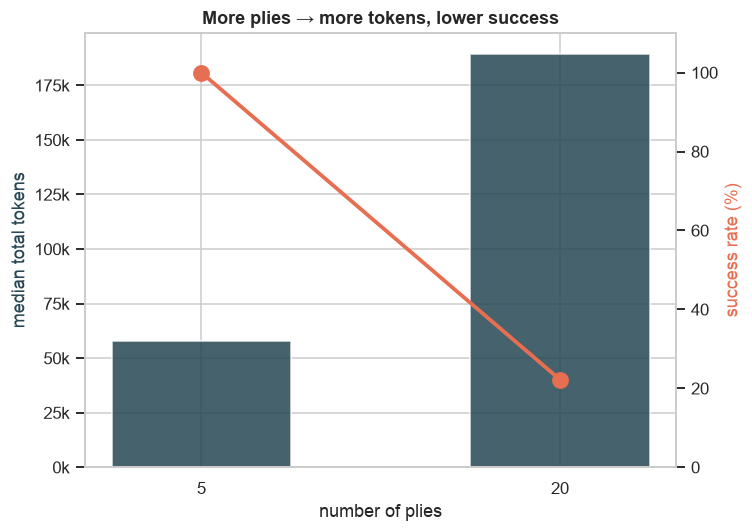

In [6]:
# Combined twin-axis: median tokens (bars) vs success rate (line) by plies
fig, ax = plt.subplots(figsize=(7, 5))
order = sorted(df["plies"].dropna().unique())
med_tok = df.groupby("plies")["total_tokens"].median().reindex(order)
sr = df.groupby("plies")["correct"].mean().reindex(order) * 100

ax.bar([str(p) for p in order], med_tok.values, color=BASE, width=0.5, alpha=0.85,
       label="median tokens")
ax.set_ylabel("median total tokens", color=BASE)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
ax.set_xlabel("number of plies")

ax2 = ax.twinx()
ax2.plot([str(p) for p in order], sr.values, "-o", color=FAIL, lw=2.5,
         markersize=10, label="success rate")
ax2.set_ylabel("success rate (%)", color=FAIL)
ax2.set_ylim(0, 110)
ax2.grid(False)
ax.set_title("More plies → more tokens, lower success")
fig.tight_layout()
plt.show()

## 2. Collective parameter effects — named presets @ 5 plies

All nine presets in study `20260622-164441` ran on the **same 5-ply problem and all
solved it correctly**, so here the interesting axis is **cost**, not success. Each
preset changes several parameters relative to `baseline`; the table below lists the
exact deltas, and the bars show how those collective changes move token usage.

In [7]:
dfc = df[df["study"] == "20260622-164441"].copy()
kp_cols = [c for c in dfc.columns if c.startswith("kp::")]
base_row = dfc[dfc["label"] == "baseline"].iloc[0]

def diff_vs_baseline(row):
    diffs = {}
    for c in kp_cols:
        if row[c] != base_row[c] and pd.notna(row[c]):
            diffs[c.replace("kp::", "")] = row[c]
    return diffs

dfc["param_changes"] = dfc.apply(diff_vs_baseline, axis=1)
dfc["changes_str"] = dfc["param_changes"].apply(
    lambda d: ", ".join(f"{k}={v}" for k, v in d.items()) if d else "— (baseline)")

show = (dfc[["label", "changes_str", "total_tokens", "output_tokens", "usd",
             "elapsed_s", "n_atoms", "correct"]]
        .sort_values("total_tokens", ascending=False)
        .reset_index(drop=True))
show

,label,changes_str,total_tokens,output_tokens,usd,elapsed_s,n_atoms,correct
0,wide_split,"pipeline.max_atoms_per_split=5, pipeline.max_n...",80962,31313,0.618642,542.13,12,True
1,K5_diverse,"pipeline.K_executor=5, pipeline.K_combiner=5, ...",71265,23276,0.493107,430.39,10,True
2,deep_split,"pipeline.max_split_depth=4, pipeline.max_node_...",61899,18145,0.403437,322.29,14,True
3,baseline,— (baseline),58267,22981,0.450573,392.44,9,True
4,lenient_verify,pipeline.verifier_accept=0.6,57921,20793,0.423279,355.18,9,True
5,big_budget,"mcts.N=128, pipeline.max_node_calls=200",54033,19002,0.390123,332.16,9,True
6,strict_verify,pipeline.verifier_accept=0.9,53720,19501,0.395172,330.76,8,True
7,shallow_split,pipeline.max_split_depth=2,42681,14672,0.304107,238.12,7,True
8,K1_cheapest,"pipeline.K_executor=1, pipeline.K_combiner=1",23649,6679,0.151095,117.29,8,True


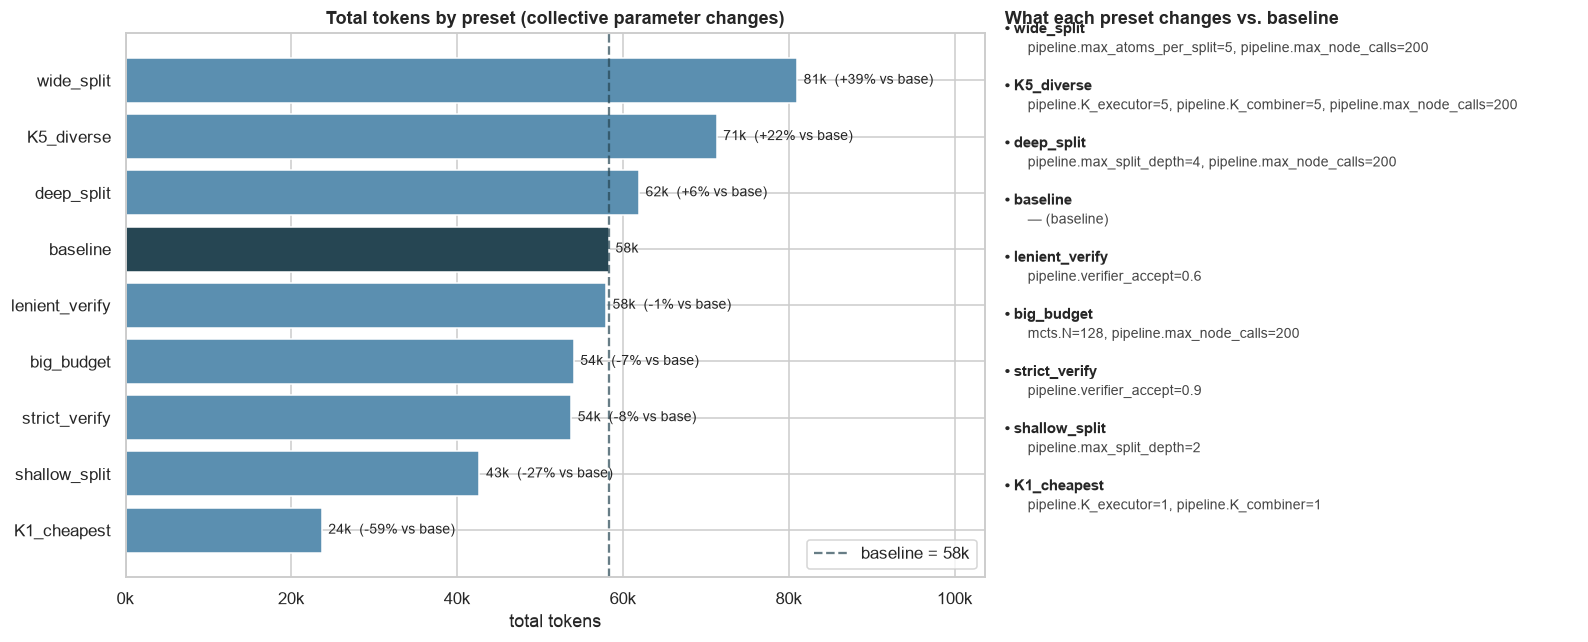

In [8]:
# Horizontal bars: total tokens per preset (baseline highlighted), annotated with deltas
d = dfc.sort_values("total_tokens")
colors = [BASE if lbl == "baseline" else "#5b8fb0" for lbl in d["label"]]

fig, (axL, axR) = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={"width_ratios": [3, 2]})

bars = axL.barh(d["label"], d["total_tokens"], color=colors)
base_tokens = base_row["total_tokens"]
axL.axvline(base_tokens, color=BASE, ls="--", lw=1.5, alpha=0.7,
            label=f"baseline = {base_tokens/1000:.0f}k")
for b, lbl, ch in zip(bars, d["label"], d["changes_str"]):
    pct = (b.get_width() - base_tokens) / base_tokens * 100
    tag = "" if lbl == "baseline" else f"  ({pct:+.0f}% vs base)"
    axL.text(b.get_width() + 800, b.get_y() + b.get_height()/2,
             f"{b.get_width()/1000:.0f}k{tag}", va="center", fontsize=9)
axL.set_title("Total tokens by preset (collective parameter changes)")
axL.set_xlabel("total tokens")
axL.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
axL.set_xlim(0, d["total_tokens"].max() * 1.28)
axL.legend(loc="lower right")

# Right: which parameters each preset changed (text panel)
axR.axis("off")
axR.set_title("What each preset changes vs. baseline", loc="left")
y = 1.0
for lbl in d["label"][::-1]:
    ch = dfc.loc[dfc["label"] == lbl, "changes_str"].iloc[0]
    axR.text(0.0, y, f"• {lbl}", fontsize=10, fontweight="bold", transform=axR.transAxes)
    axR.text(0.04, y - 0.035, ch, fontsize=9, color="#444", transform=axR.transAxes,
             wrap=True)
    y -= 0.105
fig.tight_layout()
plt.show()

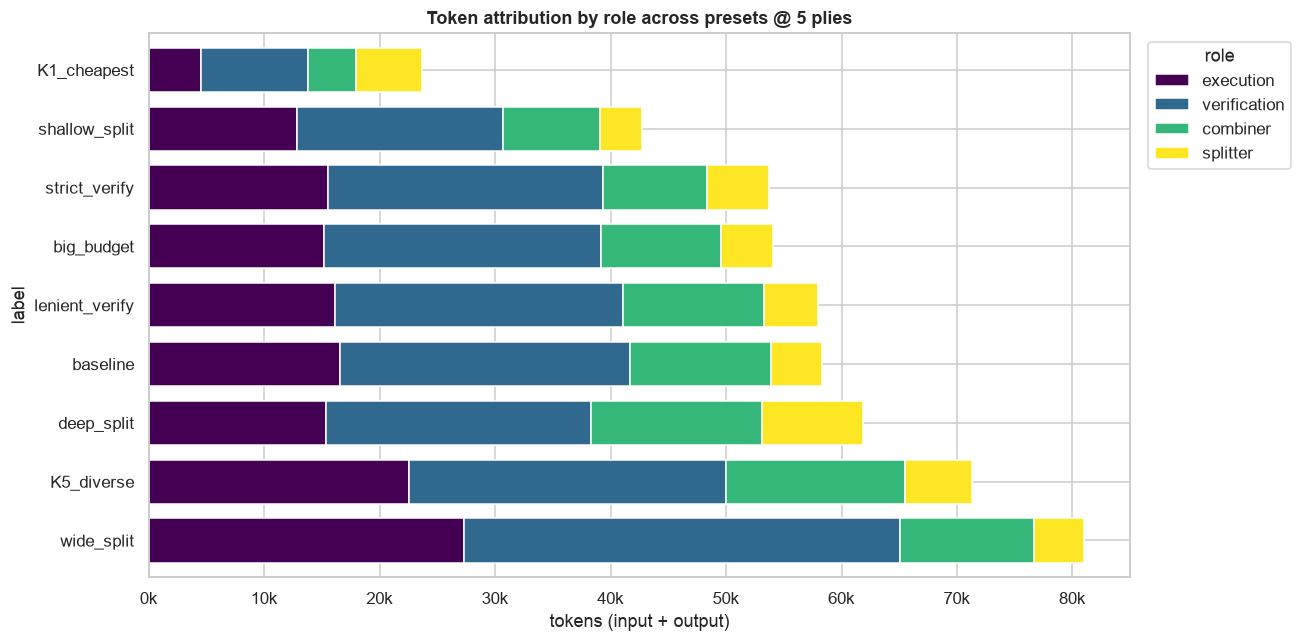

In [9]:
# Where do the tokens go? Per-role token totals, stacked per preset.
role_cols = [c for c in dfc.columns if c.startswith("role_tot::")]
role_cols = [c for c in role_cols if dfc[c].sum() > 0]          # drop unused roles
role_names = [c.replace("role_tot::", "") for c in role_cols]

stack = dfc.set_index("label")[role_cols].loc[
    dfc.sort_values("total_tokens", ascending=False)["label"]]
stack.columns = role_names

ax = stack.plot(kind="barh", stacked=True, figsize=(12, 6),
                colormap="viridis", width=0.75)
ax.set_title("Token attribution by role across presets @ 5 plies")
ax.set_xlabel("tokens (input + output)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
ax.legend(title="role", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 3. Individual parameter sweeps @ 20 plies

Study `20260622-165017` holds everything at baseline and sweeps **one** parameter at
a time on the harder **20-ply** problem. Here both **tokens** and **success** vary,
so each bar shows token cost (height) and outcome (green = solved, red = failed).

/var/folders/ym/tr7pzz9114b1_h69mftjgk_m0000gp/T/ipykernel_93527/2037741536.py:33: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/ym/tr7pzz9114b1_h69mftjgk_m0000gp/T/ipykernel_93527/2037741536.py:33: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.tight_layout()
<repo-root>/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
<repo-root>/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


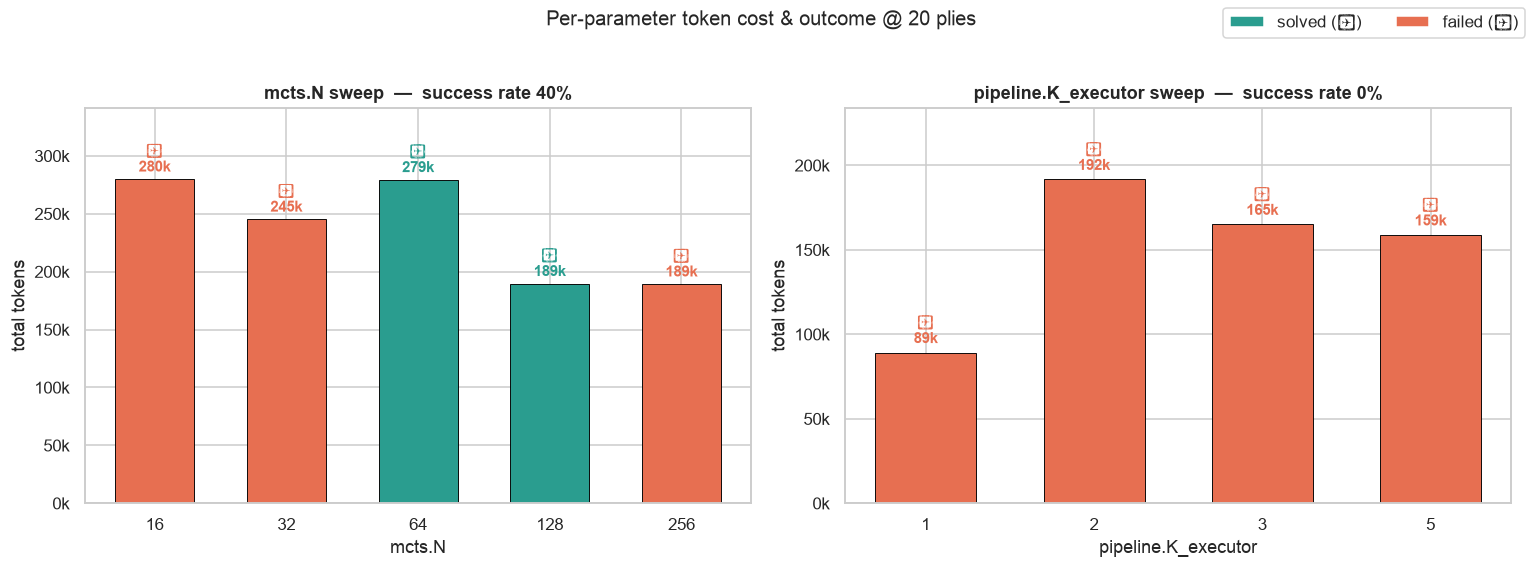

In [10]:
def plot_sweep(param, ax):
    s = (df[(df["study"] == "20260622-165017") & (df["vary"] == param)]
         .copy().sort_values("value"))
    x = s["value"].astype(int).astype(str)
    bars = ax.bar(x, s["total_tokens"],
                  color=[OK if c else FAIL for c in s["correct"]],
                  edgecolor="black", linewidth=0.6, width=0.6)
    for b, c, tok in zip(bars, s["correct"], s["total_tokens"]):
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 3000,
                ("✓" if c else "✗") + f"\n{tok/1000:.0f}k",
                ha="center", va="bottom", fontsize=10,
                color=OK if c else FAIL, fontweight="bold")
    sr = s["correct"].mean() * 100
    ax.set_title(f"{param} sweep  —  success rate {sr:.0f}%")
    ax.set_xlabel(param)
    ax.set_ylabel("total tokens")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v/1000:.0f}k"))
    ax.set_ylim(0, s["total_tokens"].max() * 1.22)

params = sorted(df[df["study"] == "20260622-165017"]["vary"].dropna().unique())
fig, axes = plt.subplots(1, len(params), figsize=(7 * len(params), 5))
if len(params) == 1:
    axes = [axes]
for p, ax in zip(params, axes):
    plot_sweep(p, ax)

# shared legend
from matplotlib.patches import Patch
fig.legend(handles=[Patch(facecolor=OK, label="solved (✓)"),
                    Patch(facecolor=FAIL, label="failed (✗)")],
           loc="upper right", ncol=2)
fig.suptitle("Per-parameter token cost & outcome @ 20 plies", fontsize=13, y=1.03)
fig.tight_layout()
plt.show()

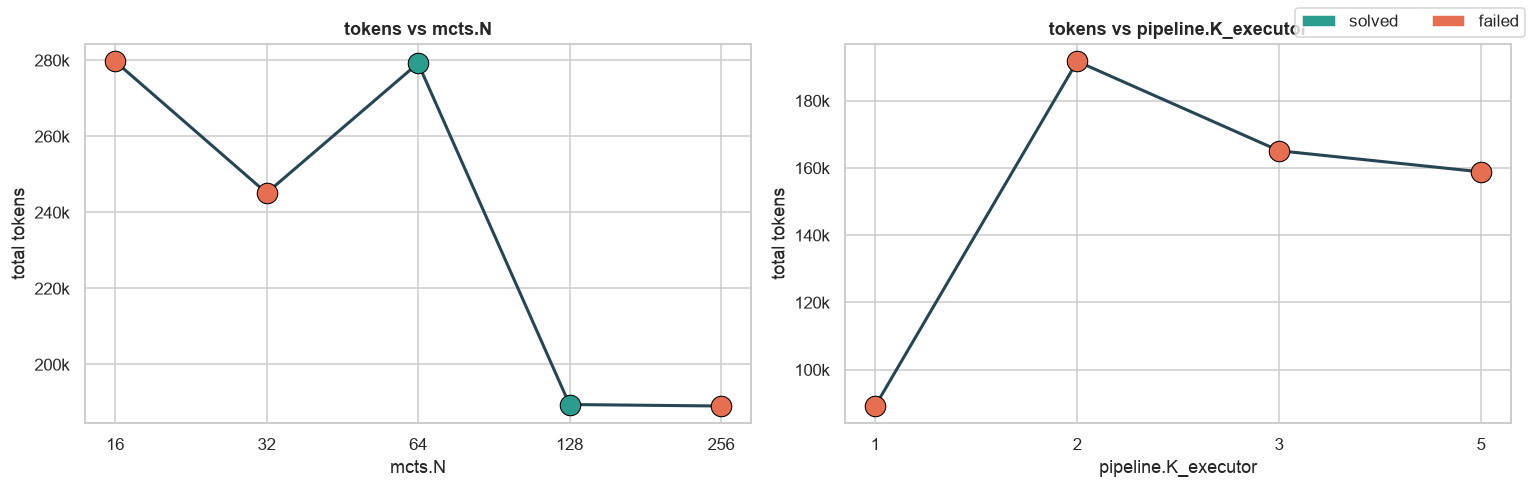

In [11]:
# Same sweeps as lines, to read the token *trend* against the parameter value.
fig, axes = plt.subplots(1, len(params), figsize=(7 * len(params), 4.5))
if len(params) == 1:
    axes = [axes]
for p, ax in zip(params, axes):
    s = (df[(df["study"] == "20260622-165017") & (df["vary"] == p)]
         .copy().sort_values("value"))
    ax.plot(s["value"].astype(int).astype(str), s["total_tokens"],
            "-o", color=BASE, lw=2, markersize=8)
    # mark outcome on each point
    for xv, tok, c in zip(s["value"].astype(int).astype(str), s["total_tokens"], s["correct"]):
        ax.scatter([xv], [tok], s=180, zorder=5,
                   color=OK if c else FAIL, edgecolor="black", linewidth=0.7)
    ax.set_title(f"tokens vs {p}")
    ax.set_xlabel(p)
    ax.set_ylabel("total tokens")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v/1000:.0f}k"))
fig.legend(handles=[Patch(facecolor=OK, label="solved"),
                    Patch(facecolor=FAIL, label="failed")],
           loc="upper right", ncol=2)
fig.tight_layout()
plt.show()

## 4. Combined summary: tokens & success by plies and study

In [12]:
summary = (df.groupby(["plies", "study_name"])
             .agg(n_runs=("label", "size"),
                  success_rate_pct=("correct", lambda s: round(100 * s.mean(), 1)),
                  median_tokens=("total_tokens", "median"),
                  min_tokens=("total_tokens", "min"),
                  max_tokens=("total_tokens", "max"),
                  median_usd=("usd", lambda s: round(s.median(), 3)),
                  median_elapsed_s=("elapsed_s", "median"))
             .reset_index())
summary

,plies,study_name,n_runs,success_rate_pct,median_tokens,min_tokens,max_tokens,median_usd,median_elapsed_s
0,5,collective (named presets),9,100.0,57921.0,23649,80962,0.403,332.16
1,20,individual (param sweeps),9,22.2,189477.0,89217,279725,1.370,1184.52


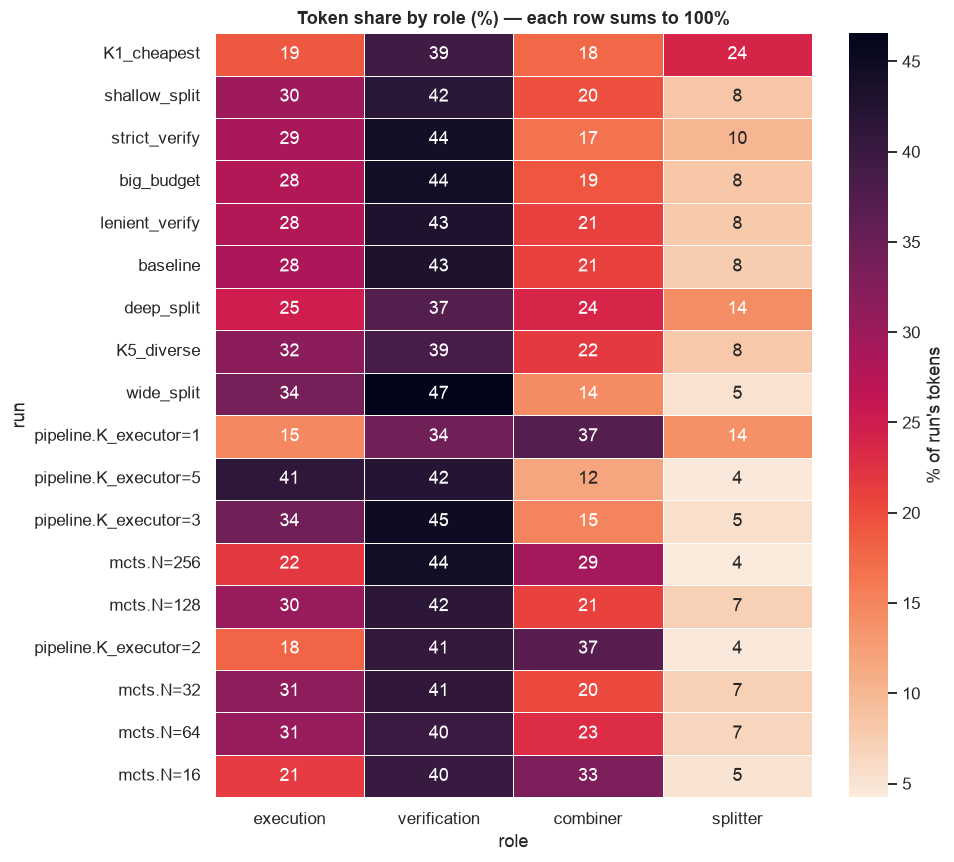

In [13]:
# Per-role token *share* heatmap across every run (where the budget goes).
role_cols = [c for c in df.columns if c.startswith("role_tot::")]
role_cols = [c for c in role_cols if df[c].sum() > 0]
heat = df.set_index("label")[role_cols]
heat.columns = [c.replace("role_tot::", "") for c in role_cols]
heat_share = heat.div(heat.sum(axis=1), axis=0) * 100   # row-normalized %

# order rows by study then plies for readability
ord_idx = df.sort_values(["plies", "study", "total_tokens"])["label"]
heat_share = heat_share.loc[ord_idx]

fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(heat_share, annot=True, fmt=".0f", cmap="rocket_r",
            cbar_kws={"label": "% of run's tokens"}, linewidths=0.5, ax=ax)
ax.set_title("Token share by role (%) — each row sums to 100%")
ax.set_xlabel("role")
ax.set_ylabel("run")
plt.tight_layout()
plt.show()

## 5. Takeaways

*(Generated from the loaded data — re-run the cell below after changing inputs.)*

In [14]:
lines = []
sr5  = df[df.plies == 5]["correct"].mean() * 100
sr20 = df[df.plies == 20]["correct"].mean() * 100
tok5  = df[df.plies == 5]["total_tokens"].median()
tok20 = df[df.plies == 20]["total_tokens"].median()
lines.append(f"• Plies dominate: 5-ply success {sr5:.0f}% vs 20-ply {sr20:.0f}%; "
             f"median tokens {tok5/1000:.0f}k → {tok20/1000:.0f}k "
             f"({tok20/tok5:.1f}x).")

# cheapest / priciest preset (collective)
c = df[df.study == '20260622-164441']
cheap = c.loc[c.total_tokens.idxmin()]; pricey = c.loc[c.total_tokens.idxmax()]
lines.append(f"• Collective (5-ply, all solved): cheapest = {cheap.label} "
             f"({cheap.total_tokens/1000:.0f}k), priciest = {pricey.label} "
             f"({pricey.total_tokens/1000:.0f}k) — a "
             f"{pricey.total_tokens/cheap.total_tokens:.1f}x spread with no accuracy cost.")

# individual sweeps
for p in sorted(df[df.study=='20260622-165017']['vary'].dropna().unique()):
    s = df[(df.vary == p)].sort_values('value')
    winners = s[s.correct]['value'].astype(int).tolist()
    lines.append(f"• {p}: solved only at value(s) {winners or 'none'} "
                 f"(success {100*s.correct.mean():.0f}% across {len(s)} settings); "
                 f"more compute did not monotonically help.")

lines.append("• Caveat: plies and study design are confounded (collective@5, "
             "individual@20); treat cross-study comparisons as regime contrasts, "
             "not controlled per-config ply sweeps.")
print("\n".join(lines))

• Plies dominate: 5-ply success 100% vs 20-ply 22%; median tokens 58k → 189k (3.3x).
• Collective (5-ply, all solved): cheapest = K1_cheapest (24k), priciest = wide_split (81k) — a 3.4x spread with no accuracy cost.
• mcts.N: solved only at value(s) [64, 128] (success 40% across 5 settings); more compute did not monotonically help.
• pipeline.K_executor: solved only at value(s) none (success 0% across 4 settings); more compute did not monotonically help.
• Caveat: plies and study design are confounded (collective@5, individual@20); treat cross-study comparisons as regime contrasts, not controlled per-config ply sweeps.


---
# 6. Cost equations — parameters → calls → tokens → USD

The repo's `cost_model.py` already fits the **pricing layer** (tokens → USD,
`cost ≈ a·in + b·out` per model, R²≈1). What it does *not* give is the
**upstream structural layer**: how the solver knobs determine the *number of
calls* in the first place. Below we derive that layer from the pipeline code and
**validate it against the logged per-role call counts**.

### 6.1 Notation (per top-level block)

| symbol | meaning | knob |
|---|---|---|
| $P$ | problem size (plies) | `--max-plies` |
| $b$ | branching factor of the split | `max_atoms_per_split` (upper bound; LLM picks $b_{\text{eff}}\le b$) |
| $D$ | realized tree depth | `max_split_depth` (cap) |
| $L$ | # leaf atoms | emergent, $L\lesssim b^{D}$, empirically $L\approx\kappa_L P$ |
| $I$ | # internal (composite) atoms | emergent, $A=L+I$ = total atoms |
| $K_e,\,K_c$ | executor / combiner samples | `K_executor`, `K_combiner` |
| $r\in[0,R]$ | realized combiner retries | $R=$ `combiner_retries` |
| $B$ | hard per-node call ceiling | `max_node_calls` |

### 6.2 Calls per role (read off the pipeline, confirmed in logs)

$$
\begin{aligned}
n_{\text{split}} &\approx I + 1 &&\text{(one split attempt per internal node + root)}\\
n_{\text{exec}}  &= K_e\,L &&\text{(K samples per leaf — \emph{exact} in logs)}\\
n_{\text{verify}}&\approx K_e\,L + (1+\bar r) &&\text{(per-sample credibility + block check)}\\
n_{\text{mini-comb}} &\approx I &&\text{(}n{=}1\text{ combine per composite)}\\
n_{\text{block-comb}}&= K_c\,(1+\bar r) &&\text{(final combine, retried)}
\end{aligned}
$$

**Total calls** (clamped by the per-node budget):

$$
\boxed{\,n_{\text{calls}} \approx \min\!\Big(B,\;
\underbrace{2K_eL}_{\text{exec+verify}}
+\underbrace{2I+1}_{\text{split+mini-comb}}
+\underbrace{(K_c+1)(1+\bar r)}_{\text{block combine+verify}}\Big)\,}
$$

Leading order $n_{\text{calls}}=\Theta(K_e\,L)=\Theta(K_e\,b^{D})$ — **the executor (and its paired verifier) dominate.**

### 6.3 Tokens and USD (compose with the pricing layer)

With $\bar t^{\text{in}}_\rho,\bar t^{\text{out}}_\rho$ = mean in/out tokens per call of role $\rho$ (measured), role $\rho$ routed to model $m(\rho)$ at prices $\pi^{\text{in}}_m,\pi^{\text{out}}_m$ (\$/Mtok):

$$
\text{tokens}\approx\sum_\rho n_\rho\big(\bar t^{\text{in}}_\rho+\bar t^{\text{out}}_\rho\big),
\qquad
\text{USD}\approx\sum_\rho n_\rho\,\frac{\pi^{\text{in}}_{m(\rho)}\bar t^{\text{in}}_\rho+\pi^{\text{out}}_{m(\rho)}\bar t^{\text{out}}_\rho}{10^6}.
$$

### 6.4 Plies dependence and parameter sensitivities

Empirically $L\approx\kappa_L P$ and $A\approx\kappa_A P$, so

$$
\text{tokens}\;\approx\;\big(2K_e\,\kappa_L P\big)\,\bar t \;+\;\text{const}
\quad\Longrightarrow\quad
\text{cost}\sim K_e\cdot P .
$$

| knob | effect on cost | why |
|---|---|---|
| `K_executor` $\uparrow$ | **linear ↑ (dominant)** | scales exec + verify, the two biggest terms |
| `K_combiner` $\uparrow$ | linear ↑ (small) | only the block-combine term |
| `max_split_depth`,`max_atoms_per_split` $\uparrow$ | ↑ via larger $L\!=\!b^{D}$ | more atoms to execute/verify |
| `combiner_retries`,`verifier_accept` $\uparrow$ | ↑ $\bar r$ ⇒ ↑ combine/verify | higher accept ⇒ more rejections ⇒ more retries |
| `mcts.N` $\uparrow$ | ~flat / non-monotone | early-stop ⇒ realized rollouts $<N$; bigger $N$ often *converged to fewer atoms* in our data |
| `confidence.alpha` | second-order | no direct calls; only reweights selection/early-stop |
| `max_node_calls` $B$ | clamps | cost saturates at $B$ per node |


In [15]:
# --- 6.5 Validate the structural call-count model against the logs ----------
def load_calls():
    rows = []
    for study in STUDIES:
        jl = os.path.join(PROJECT_ROOT, "results", "chess_study", study, "runs.jsonl")
        for line in open(jl):
            o = json.loads(line)
            prc, kp = o["per_role_cost"], o["key_params"]
            cc = lambda role: prc.get(role, {}).get("calls", 0)
            rows.append(dict(
                study=study, label=o["label"],
                Ke=kp["pipeline.K_executor"], Kc=kp["pipeline.K_combiner"],
                R=kp["pipeline.combiner_retries"],
                accept=kp["pipeline.verifier_accept"], N=kp["mcts.N"],
                A=o["n_atoms"],
                exec_c=cc("execution"), verif_c=cc("verification"),
                split_c=cc("splitter"), comb_c=cc("combiner"),
                total_c=o["cost"]["calls"], total_tokens=o["cost"]["total_tokens"],
                usd=o["cost"]["usd"], correct=bool(o["overall_correct"])))
    return pd.DataFrame(rows)

cdf = load_calls().merge(df[["study", "label", "plies"]], on=["study", "label"])

# Realized decomposition: leaves L follow exactly from exec = Ke * L.
cdf["L"] = (cdf["exec_c"] / cdf["Ke"]).round().astype(int)
cdf["I"] = (cdf["A"] - cdf["L"]).clip(lower=0)

# Structural predictions (assume first-pass accept, r=0; +1 block verify).
cdf["exec_pred"]  = cdf["Ke"] * cdf["L"]
cdf["split_pred"] = cdf["I"] + 1
cdf["comb_pred"]  = cdf["I"] + cdf["Kc"] * 1
cdf["verif_pred"] = cdf["Ke"] * cdf["L"] + 1
cdf["total_pred"] = cdf[["exec_pred", "split_pred", "comb_pred", "verif_pred"]].sum(axis=1)

def r2(obs, pred):
    obs, pred = np.asarray(obs, float), np.asarray(pred, float)
    ss_res = float(((obs - pred) ** 2).sum())
    ss_tot = float(((obs - obs.mean()) ** 2).sum())
    return 1 - ss_res / ss_tot if ss_tot else float("nan")

print("Structural call-count model vs observed total calls:")
print(f"  R^2  = {r2(cdf['total_c'], cdf['total_pred']):.3f}")
print(f"  MAPE = {(np.abs(cdf['total_c']-cdf['total_pred'])/cdf['total_c']).mean()*100:.1f}%")
cdf[["label", "plies", "Ke", "Kc", "L", "I", "A",
     "total_pred", "total_c"]].sort_values("plies").reset_index(drop=True)

Structural call-count model vs observed total calls:
  R^2  = 0.959
  MAPE = 6.9%


,label,plies,Ke,Kc,L,I,A,total_pred,total_c
0,baseline,5,3,3,6,3,9,47,46
1,strict_verify,5,3,3,6,2,8,45,48
2,big_budget,5,3,3,6,3,9,47,47
3,K5_diverse,5,5,5,7,3,10,83,75
4,lenient_verify,5,3,3,6,3,9,47,46
5,wide_split,5,3,3,10,2,12,69,68
6,deep_split,5,3,3,9,5,14,69,65
7,shallow_split,5,3,3,5,2,7,39,38
8,K1_cheapest,5,1,1,6,2,8,19,22
9,pipeline.K_executor=3,20,3,3,12,6,18,89,87


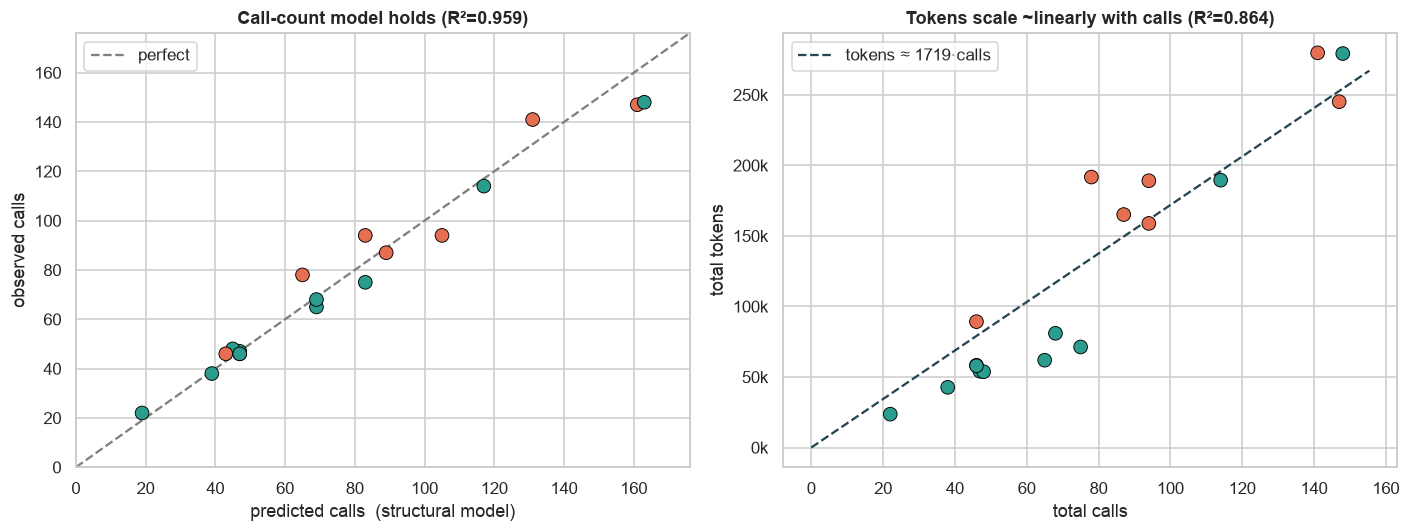

Average tokens per call across all runs: 1719


In [16]:
# Visual: predicted vs observed calls, and tokens-per-call linearity.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.scatter(cdf["total_pred"], cdf["total_c"],
            c=[OK if c else FAIL for c in cdf["correct"]], s=80,
            edgecolor="black", linewidth=0.6, zorder=3)
lim = [0, cdf[["total_pred", "total_c"]].to_numpy().max() * 1.08]
ax1.plot(lim, lim, "--", color="grey", label="perfect")
ax1.set_xlim(lim); ax1.set_ylim(lim)
ax1.set_xlabel("predicted calls  (structural model)")
ax1.set_ylabel("observed calls")
ax1.set_title(f"Call-count model holds (R²={r2(cdf['total_c'], cdf['total_pred']):.3f})")
ax1.legend(loc="upper left")

# tokens vs calls: tokens ≈ tbar * calls (through origin)
c, t = cdf["total_c"].values.astype(float), cdf["total_tokens"].values.astype(float)
tbar = float((c * t).sum() / (c * c).sum())          # OLS through origin
ax2.scatter(c, t, c=[OK if x else FAIL for x in cdf["correct"]], s=80,
            edgecolor="black", linewidth=0.6, zorder=3)
xs = np.array([0, c.max() * 1.05])
ax2.plot(xs, tbar * xs, "--", color=BASE,
         label=f"tokens ≈ {tbar:.0f}·calls")
ax2.set_xlabel("total calls"); ax2.set_ylabel("total tokens")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
ax2.set_title(f"Tokens scale ~linearly with calls (R²={r2(t, tbar*c):.3f})")
ax2.legend(loc="upper left")
fig.tight_layout(); plt.show()

print(f"Average tokens per call across all runs: {tbar:.0f}")

In [17]:
# Mean tokens/call per role (the t̄ coefficients for the USD equation).
def per_call_tokens():
    rows = []
    for study in STUDIES:
        jl = os.path.join(PROJECT_ROOT, "results", "chess_study", study, "runs.jsonl")
        for line in open(jl):
            o = json.loads(line)
            for role, c in o["per_role_cost"].items():
                if c["calls"]:
                    rows.append(dict(role=role,
                                     in_per_call=c["input_tokens"] / c["calls"],
                                     out_per_call=c["output_tokens"] / c["calls"]))
    g = pd.DataFrame(rows).groupby("role").mean().round(0)
    g["tot_per_call"] = g["in_per_call"] + g["out_per_call"]
    return g.sort_values("tot_per_call", ascending=False)

print("Mean tokens per call by role  (t̄_in, t̄_out for the USD equation):")
per_call_tokens()

Mean tokens per call by role  (t̄_in, t̄_out for the USD equation):


,in_per_call,out_per_call,tot_per_call
role,,,
combiner,2398.0,439.0,2837.0
verification,1292.0,313.0,1605.0
splitter,769.0,491.0,1260.0
execution,256.0,790.0,1046.0


---
# 7. Solvability equations — expected success per decomposition level

### 7.1 Per-atom effective success

A single executor sample solves an atom with probability $q_0$ (model- and
difficulty-dependent). With $K_e$ samples, a verifier of sensitivity $s$ gated at
$\tau=$ `verifier_accept`, and up to $R$ combiner retries, the **effective
per-atom success** is the chance that *at least one* accepted sample is correct:

$$
\boxed{\,q_{\text{eff}} \;\approx\; 1-\big(1-s\,q_0\big)^{\,K_e\,(1+\bar r)}\,}
$$

↑ `K_executor`, ↑ `combiner_retries` raise $q_{\text{eff}}$ (with diminishing
returns); ↑ `verifier_accept` raises precision $s$ but rejects borderline-correct
answers (lower recall) and spends retries.

### 7.2 Per-level solvability

A decomposition **level** $\ell$ is the tree depth (the logs' `levels[ℓ]`). If a
level holds $n_\ell$ atoms that must *all* be right for the slice to stay faithful:

$$
\boxed{\,P_\ell \;=\; q_{\text{eff}}^{\,n_\ell}\,}
\qquad\text{estimated by the logged } \texttt{pass\_rate}_\ell
\ (\text{from } n_{\text{gradeable},\ell}\ \text{samples}).
$$

### 7.3 Overall solvability — geometric decay in problem size

Chess board-match needs the **entire** move chain correct (one bad atom corrupts
the board), so every atom across every level must pass:

$$
\boxed{\,P_{\text{solve}} \;\approx\; \prod_{\ell=1}^{D} P_\ell
\;=\; q_{\text{eff}}^{\;\sum_\ell n_\ell}
\;=\; q_{\text{eff}}^{\,A}
\;\approx\; q_{\text{eff}}^{\,\kappa_A P}\,}
$$

**This is the central law:** solvability decays *geometrically* in the atom count
$A$ (≈ plies $P$), while §6 showed cost grows only *linearly*. Below we fit a
single $q_{\text{eff}}$ to all 18 runs by maximum likelihood on
$P_{\text{solve}}=q^{A}$ and check it against the 5- vs 20-ply success rates.

MLE effective per-atom success q_eff = 0.9671
   5 plies: A= 9.6 | observed  100% | global q^A=  73% | q_regime>0.930 (no failures)
  20 plies: A=22.9 | observed   22% | global q^A=  47% | q_regime=0.936


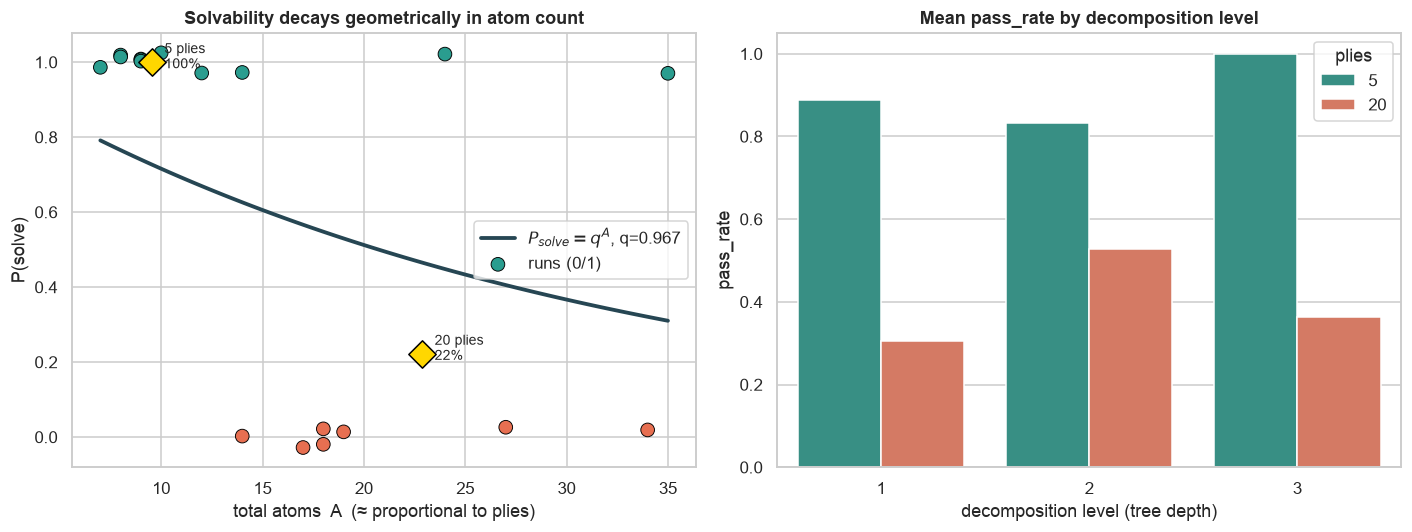


Note: level pass_rate is a SPARSE estimate — only a few atoms per level are gradeable, so treat per-level numbers as noisy.


In [18]:
# --- 7.4 Fit q_eff from P_solve = q^A by maximum likelihood -----------------
A = cdf["A"].values.astype(float)
y = cdf["correct"].values.astype(float)

qs = np.linspace(0.80, 0.999, 600)
def loglik(q):
    p = np.clip(q ** A, 1e-9, 1 - 1e-9)
    return float((y * np.log(p) + (1 - y) * np.log(1 - p)).sum())
ll = np.array([loglik(q) for q in qs])
q_hat = float(qs[ll.argmax()])
print(f"MLE effective per-atom success q_eff = {q_hat:.4f}")

# regime check — a single global q is a compromise; per-regime q is sharper,
# because per-atom success itself drops as the problem gets harder.
for pl in sorted(cdf["plies"].unique()):
    sub = cdf[cdf["plies"] == pl]
    A_bar = sub["A"].mean(); sr = sub["correct"].mean()
    q_reg = sr ** (1 / A_bar) if 0 < sr < 1 else float("nan")
    q_txt = (f"q_regime>{0.5**(1/A_bar):.3f} (no failures)" if sr == 1
             else f"q_regime={q_reg:.3f}")
    print(f"  {pl:>2} plies: A={A_bar:4.1f} | observed {sr*100:4.0f}% | "
          f"global q^A={q_hat**A_bar*100:4.0f}% | {q_txt}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Left: P_solve = q^A curve vs observed outcomes
xs = np.linspace(A.min(), A.max(), 100)
ax1.plot(xs, q_hat ** xs, "-", color=BASE, lw=2.5,
         label=f"$P_{{solve}}=q^{{A}}$, q={q_hat:.3f}")
rng = np.random.default_rng(0)  # tiny y-jitter so points don't overlap
ax1.scatter(A, y + rng.uniform(-0.03, 0.03, size=len(y)),
            c=[OK if c else FAIL for c in cdf["correct"]], s=80,
            edgecolor="black", linewidth=0.6, zorder=3, label="runs (0/1)")
for pl in sorted(cdf["plies"].unique()):
    sub = cdf[cdf["plies"] == pl]
    ax1.scatter([sub["A"].mean()], [sub["correct"].mean()], marker="D", s=160,
                color="gold", edgecolor="black", zorder=5)
    ax1.annotate(f"{pl} plies\n{sub['correct'].mean()*100:.0f}%",
                 (sub["A"].mean(), sub["correct"].mean()),
                 textcoords="offset points", xytext=(8, -4), fontsize=9)
ax1.set_xlabel("total atoms  A  (≈ proportional to plies)")
ax1.set_ylabel("P(solve)")
ax1.set_title("Solvability decays geometrically in atom count")
ax1.legend(loc="center right")

# Right: per-level pass_rate (sparse but informative)
lv_rows = []
for study in STUDIES:
    jl = os.path.join(PROJECT_ROOT, "results", "chess_study", study, "runs.jsonl")
    for line in open(jl):
        o = json.loads(line)
        for lv, d in o["levels"].items():
            if d.get("pass_rate") is not None:
                lv_rows.append(dict(plies=5 if "164441" in study else 20,
                                    level=int(lv), pass_rate=d["pass_rate"],
                                    gradeable=d["gradeable"]))
lvdf = pd.DataFrame(lv_rows)
sns.barplot(data=lvdf, x="level", y="pass_rate", hue="plies", ax=ax2,
            palette={5: OK, 20: FAIL}, errorbar=None)
ax2.set_ylim(0, 1.05)
ax2.set_title("Mean pass_rate by decomposition level")
ax2.set_xlabel("decomposition level (tree depth)")
ax2.set_ylabel("pass_rate")
ax2.legend(title="plies")
fig.tight_layout(); plt.show()
print("\nNote: level pass_rate is a SPARSE estimate — only a few atoms per level "
      "are gradeable, so treat per-level numbers as noisy.")

In [19]:
# --- 7.5 What the model implies: more sampling can't rescue a deep problem --
print("Implication of P_solve = q_eff^A  (A ≈ 25 atoms at 20 plies):")
A_hard = cdf[cdf["plies"] == 20]["A"].mean()
for q in [0.90, 0.94, 0.97, 0.99]:
    print(f"  q_eff={q:.2f}  ->  P_solve = {q**A_hard*100:5.1f}%   (A={A_hard:.0f})")
print(f"\nObserved q_eff≈{q_hat:.3f}. Pushing q_eff 0.94->0.97 (more K_executor / "
      f"retries) only lifts P_solve ~0.22->~0.47; reaching ~0.78 needs q_eff~0.99,")
print("which sampling alone rarely delivers. => reducing A (shallower / fewer atoms,")
print("i.e. better decomposition) beats spending more compute per atom.")

Implication of P_solve = q_eff^A  (A ≈ 25 atoms at 20 plies):
  q_eff=0.90  ->  P_solve =   9.0%   (A=23)
  q_eff=0.94  ->  P_solve =  24.3%   (A=23)
  q_eff=0.97  ->  P_solve =  49.8%   (A=23)
  q_eff=0.99  ->  P_solve =  79.5%   (A=23)

Observed q_eff≈0.967. Pushing q_eff 0.94->0.97 (more K_executor / retries) only lifts P_solve ~0.22->~0.47; reaching ~0.78 needs q_eff~0.99,
which sampling alone rarely delivers. => reducing A (shallower / fewer atoms,
i.e. better decomposition) beats spending more compute per atom.


---
## 8. Summary of the model

**Cost** (parameters → \$):
$$
n_{\text{calls}}\approx\min\!\big(B,\;2K_eL+2I+1+(K_c+1)(1+\bar r)\big),\quad
\text{USD}\approx\sum_\rho n_\rho\frac{\pi^{\text{in}}_{m}\bar t^{\text{in}}_\rho+\pi^{\text{out}}_{m}\bar t^{\text{out}}_\rho}{10^{6}} .
$$
Dominated by the executor/verifier; **linear in `K_executor` and in atom count $L\!\approx\!\kappa_L P$**; nearly flat in `mcts.N`.

**Solvability** (per level and overall):
$$
P_\ell=q_{\text{eff}}^{\,n_\ell},\qquad
P_{\text{solve}}=q_{\text{eff}}^{\,A},\qquad
q_{\text{eff}}\approx1-(1-s\,q_0)^{K_e(1+\bar r)} .
$$
**Geometric decay in $A$ (≈ plies)** — the reason 5-ply is trivial and 20-ply mostly fails.

**The tension:** cost $\sim K_e\,A$ (linear) vs. success $\sim q_{\text{eff}}^{\,A}$
(geometric). For long games the winning lever is **shrinking $A$** (decomposition
quality / depth), not buying more samples per atom.

> Caveats: $L$, $I$ and $\bar r$ are emergent from the LLM splitter/verifier and
> are the stochastic inputs to the cost formula (we validated the formula on the
> *realized* decomposition). $q_{\text{eff}}$ is fit from 18 runs across two
> confounded regimes, and per-level `pass_rate` is sparse — treat the constants as
> order-of-magnitude, the functional forms as the takeaway.